# Angular velocity of forward swimming cells

This script quantifies the angular velocity (rotation about the cell axis) during directed swimming. 
It is required that cell body features have already been tracked using CoTracker (https://doi.org/10.48550/arXiv.2307.07635)

**Input:**

*main_path* : The path to the folder containg the input files

*output_tracking_file* : The name of the file containing the trajectories of the surface features

*registered_timelapse_file*   : The name of the file of the registered timelapse of the swimming cell

*input_parameters_path* : Path to the csv file with the relevant input parameters

*radii_in_order_path* : Path to the csv file with the radius corresponding to each feature

**Output:**

*forward_angular_velocity.csv* : A csv file with the measured angular velocity of the cell

In [ ]:
import os
import csv
import tifffile as tiff
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from functions import *

### Input

In [2]:
### Path to the main folder:
main_path = "C:\\Users\\kourkoul\SCRIPTS\\Paper_scripts\\example_data\\"

### Load the trajectories of the surface features:
output_tracking_file = main_path + "feature_tracks.npy"
output_tracking = np.load(output_tracking_file)
points = output_tracking[0] # remove the unecessary first dimension

### Load the registered timelapse:
registered_timelapse_file = main_path + "image_registered_2.tif"
tiff_pystackreg = tiff.imread(registered_timelapse_file)

### Reading the parameters file
input_parameters_path = main_path + "parameters.csv"
input_parameters = pd.read_csv(input_parameters_path)

### Pixel size and framerate of timelapse:
pixel_size = input_parameters["pixel_size"][0]  # μm 
fps        = input_parameters["fps"][0]         # frame rate

### Loading the radius file
radii_in_order_path = main_path + "radii_in_order.csv"
radii_in_order = pd.read_csv(radii_in_order_path)
radius_all_in_order = radii_in_order["radius (pixel)"].tolist()
radius_all_in_order = np.array(radius_all_in_order)* pixel_size




output_path = main_path+ "\\output_motility\\"
if not os.path.exists(output_path):
    os.makedirs(output_path)


### Define cell axis

In [3]:
### Draw a line from the anterior to the posterior of the cell, passing from its center to define teh cell axis
%matplotlib qt

frame_index = 50
image_preview = tiff_pystackreg[frame_index,:,:]
output_line_file = output_path + "selected_points.csv"

select_points_line_and_save(image_preview, output_line_file)

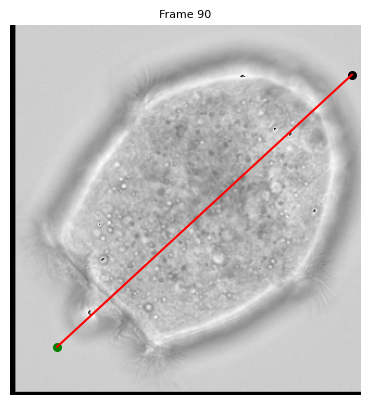

In [4]:
### Visuallize selected line
%matplotlib inline
line_borders = read_line_borders_to_array(output_line_file)

frame_index = 90   

x1, y1 = line_borders[0]
x2, y2 = line_borders[1]

plt.figure()
plt.imshow(tiff_pystackreg[frame_index], cmap = 'gray')
plt.scatter(x1, y1, c= 'green', s = 30)
plt.scatter(x2, y2, c= 'black', s = 30)
plt.plot([x1, x2], [y1, y2], c= 'r')

plt.title("Frame " + str(frame_index), fontsize = 8)
plt.axis(False)
plt.show()


In [5]:
### Definitions of relevant points
# Point at anterior:
x1 = line_borders[0][0]
y1 = line_borders[0][1]
# Point at posterior:
x2 = line_borders[1][0]
y2 = line_borders[1][1]

vector_to_anterior = (x1 - x2, y1 - y2)
perpendicular_vector = (-vector_to_anterior[1]*3/4, vector_to_anterior[0]*3/4) 

# for visualization:
displacement = (vector_to_anterior[0] / 2 - perpendicular_vector[0] / 2 , vector_to_anterior[1] / 2 - perpendicular_vector[1] / 2)
displaced_start = (x2 + displacement[0], y2 + displacement[1])


### Project feature trajectories on perpendicular vector

As the cell axis can tilt upwards or downwards compared to the focus plane, feature trajectories appear diagonal to the cell axis. 
The angular velocity around the cell axis should be calculated only by the trajectory component projected 
to a plane perpendicular to the cell axis.

In [6]:
### Projection of trajectories to the perpendicular vector
def project_onto_line(point, origin, vector):
    # Vector from origin to the point
    to_point = point - origin
    # Projection calculation
    projection_length = np.dot(to_point, vector)
    projection = origin + projection_length * vector
    return projection

frame_stop = -1
points_until_stop = points[:frame_stop,:,:]

# Define the origin point
origin_point_a = np.array([x2, y2])  # Example point in (x, y)
origin_point_b = np.array([x1 + (x2-x1)/2, y2 + (y1-y2)/2])

# Normalize the vectors
vector_to_anterior_norm = vector_to_anterior / np.linalg.norm(vector_to_anterior)
perpendicular_vector_norm = perpendicular_vector / np.linalg.norm(perpendicular_vector)

# Initialize arrays for projected points
projected_a = np.zeros_like(points_until_stop)
projected_p = np.zeros_like(points_until_stop)

# Calculate the projections
for t in range(points_until_stop.shape[0]):
    for p in range(points_until_stop.shape[1]):
        current_point = points_until_stop[t, p]
        projected_a[t, p] = project_onto_line(current_point, origin_point_a, vector_to_anterior_norm)
        projected_p[t, p] = project_onto_line(current_point, origin_point_b, perpendicular_vector_norm)


C:\Users\kourkoul\AppData\Local\Temp\ipykernel_25192\2366410489.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab20', points_until_stop.shape[1])


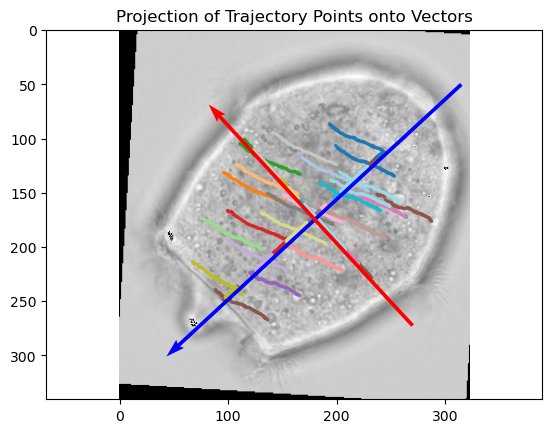

In [7]:
### Difine colormap with distinct colors for each track
colors = cm.get_cmap('tab20', points_until_stop.shape[1])  

### Plot the original trajectories
plt.figure()
plt.imshow(tiff_pystackreg[frame_stop], cmap="gray")

for p in range(points_until_stop.shape[1]):
    point_color = colors(p)
    plt.scatter(points_until_stop[:, p, 0], points_until_stop[:, p, 1],s= 2,color=point_color, label=f'Point ID {p}' if t == 0 else "", alpha=0.5)
  
for p in range(points_until_stop.shape[1]):
    point_color = colors(p)
    plt.scatter(projected_a[:, p, 0], projected_a[:, p, 1],color=point_color,  marker='x', s= 2, label=f'Projection on Vector to Anterior ID {p}')
    plt.scatter(projected_p[:, p, 0], projected_p[:, p, 1], color=point_color, marker='x', s= 2, label=f'Projection on Perpendicular Vector ID {p}')

plt.quiver(x2, y2+5, vector_to_anterior[0], vector_to_anterior[1], angles='xy', scale_units='xy', scale=1, color='b', label='Cell axis vector')
plt.quiver(displaced_start[0]-3, displaced_start[1], perpendicular_vector[0], perpendicular_vector[1], angles='xy', scale_units='xy', scale=1, color='r', label='Perpendicular Vector')

plt.title('Projection of Trajectory Points onto Vectors')
plt.axis('equal')
plt.show()

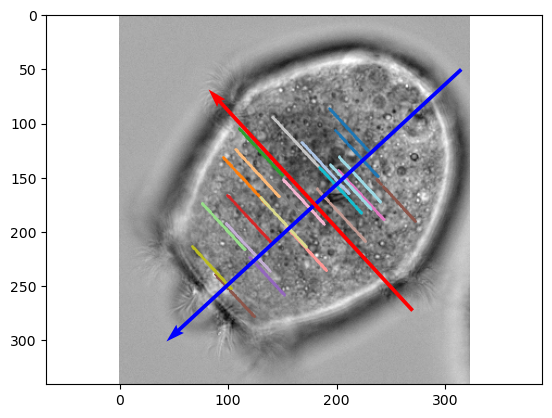

In [8]:
### Plot the projected trajectories
plt.figure()
for i in range(points_until_stop.shape[1]):
    point_color = colors(i)
    trajectories = projected_p[:,i,:]
    plt.scatter(trajectories[:,0] + (points[0,i,0] - trajectories[0,0]),trajectories[:,1] + (points[0,i,1] - trajectories[0,1]), color=point_color, s=2, marker =".") 

plt.quiver(x2, y2+5, vector_to_anterior[0], vector_to_anterior[1], angles='xy', scale_units='xy', scale=1, color='b', label='Cell axis vector')
plt.quiver(displaced_start[0]-3, displaced_start[1], perpendicular_vector[0], perpendicular_vector[1], angles='xy', scale_units='xy', scale=1, color='r', label='Perpendicular Vector')

plt.imshow(tiff_pystackreg[0], cmap="gray") 
plt.axis('equal')
plt.savefig(output_path + "projection.png")

### Calculation of Ω

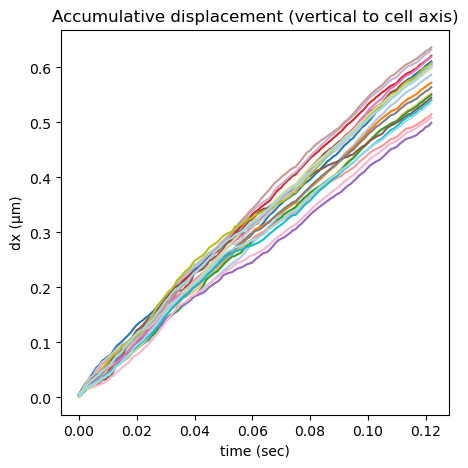

In [9]:
### Calculate the displacement perpendicular to cell axis
inst_displacement_p = np.diff(projected_p, axis = 0)
dx_p = np.linalg.norm(inst_displacement_p, axis=2)
dx_p = dx_p[..., np.newaxis]
accumulative_displacement_p = np.cumsum(dx_p* pixel_size, axis=0)
time_p =  np.arange(0, points_until_stop.shape[0]-1) /fps
dt_p = 1/fps
du_p = dx_p * pixel_size / dt_p

include = np.arange(points.shape[1])
isolated_data = []

for k in range(0, points.shape[1]):
    if k in include:
        isolated_data.append(accumulative_displacement_p[:, k, :])    

isolated_data = np.array(isolated_data)
isolated_data = np.transpose(isolated_data, (1, 0, 2))

plt.figure(figsize= (5,5))

assistant_index = 0
isolated_data_normalized = []
for k in range(0, points.shape[1]):
    if k in include:
        point_color = colors(k)
        plt.plot(time_p, accumulative_displacement_p[:,k,:]/radius_all_in_order[assistant_index]  , color = point_color )
        isolated_data_normalized.append(accumulative_displacement_p[:,k,:]/radius_all_in_order[assistant_index])
        assistant_index += 1
isolated_data_normalized = np.array(isolated_data_normalized)
isolated_data_normalized = np.transpose(isolated_data_normalized, (1, 0, 2))    
plt.title("Accumulative displacement (vertical to cell axis)")
plt.xlabel("time (sec)")
        
plt.ylabel("dx (\u03BCm)")   

plt.show()


angular velocity (rad/sec) =  4.734011759833793
error (rad/sec) =  0.3619094978886927


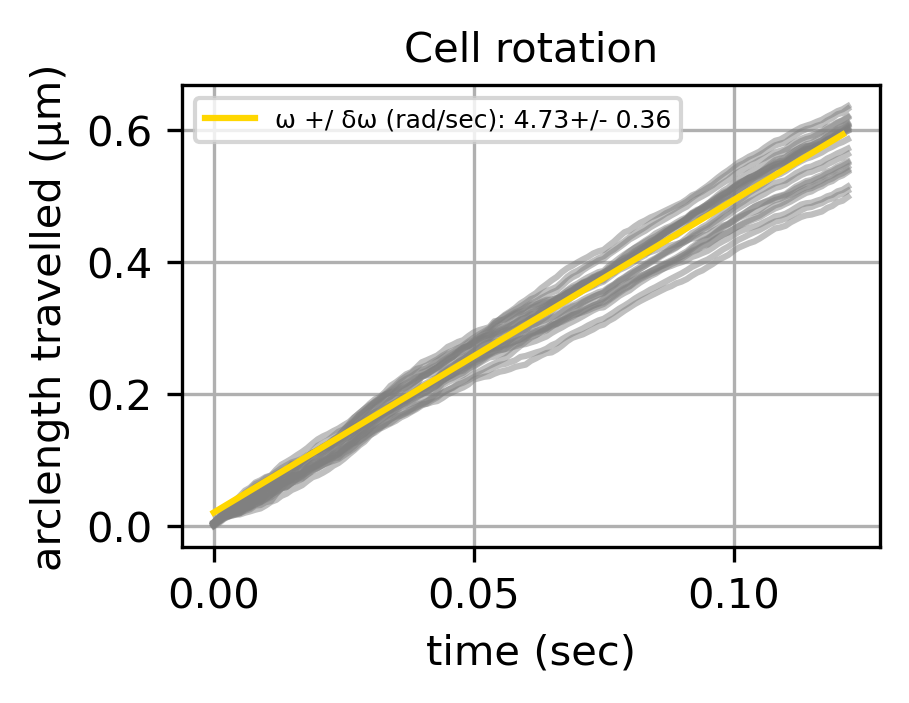

In [ ]:
frame_start = 0
frame_cut =  -1 

small_segment = isolated_data_normalized[frame_start:frame_cut,0:,:]

velocities = np.zeros(small_segment.shape[1])
intercepts = np.zeros(small_segment.shape[1])

# Linear fit for each track
for point in range(small_segment.shape[1]):
    displacement_data = small_segment[:, point, 0]  # shape (50,)
    slope, intercept, r_value, p_value, std_err = linregress(time_p[frame_start:frame_cut], displacement_data)
    velocities[point] = slope
    intercepts[point] = intercept

    
velocities_mean = np.mean(velocities)
print("angular velocity (rad/sec) = ",velocities_mean)
std_error_from_all_points = np.std(velocities)
print("error (rad/sec) = ", std_error_from_all_points)

fontsize= 10

assistant_index =0
plt.figure(figsize=(3,2), dpi=300)
for k in range(0, points.shape[1]):
    if k in include:
        point_color = colors(k)
        plt.plot(time_p[0:], accumulative_displacement_p[0:,k,:]/radius_all_in_order[assistant_index]  , color = 'gray', alpha=0.5)#point_color )
        if k == include[-1]:
            plt.plot(time_p[frame_start:frame_cut], velocities_mean*time_p[frame_start:frame_cut] + intercepts[-1] , color="gold" ,label = "\u03C9 +/ \u03B4\u03C9 (rad/sec): " +str(np.round(velocities_mean,2))+"+/- "+ str(np.round(std_error_from_all_points,2)) )
        assistant_index += 1
        
plt.title("Cell rotation",fontsize=fontsize)
plt.xlabel("time (sec)",fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)        
plt.ylabel("arclength travelled (\u03BCm)")  
plt.legend(fontsize=6)
plt.grid(True)
plt.savefig(output_path + "fit_angular_velocity.png", dpi=300, bbox_inches='tight', pad_inches=0.1)

In [16]:
def save_csv_file(output_path, headers, data):
    """
    Saves fileparameters or results in csv file.
    """
    with open(output_path, 'a', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(headers)
        writer.writerow(data)
    return

headers_param = ['file_name','pixel_size', 'fps', 'x1', 'y1', 'x2', 'y2', 'velocities', 'intercepts','fit_error','velocities_mean',  'std_error_from_all_points']
data_parameters = [' ', pixel_size, fps, x1, y1, x2, y2, velocities, intercepts, fit_error, velocities_mean, std_error_from_all_points]
save_csv_file(output_path+'forward_ang_velocity.csv', headers_param, data_parameters)
    
